In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
set(df["Cabin"].str[0])

{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', nan}

In [8]:
for letter in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']:
    total = len(df[df["Cabin"].str.startswith(letter, na=False)])
    survived = len(df[(df["Cabin"].str.startswith(letter, na=False)) & (df["Survived"] == 1)])
    print(f"Cabin {letter}: total={total}, survived={survived}")

Cabin A: total=15, survived=7
Cabin B: total=47, survived=35
Cabin C: total=59, survived=35
Cabin D: total=33, survived=25
Cabin E: total=32, survived=24
Cabin F: total=13, survived=8
Cabin G: total=4, survived=2
Cabin T: total=1, survived=0


In [9]:
for letter in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']:
    fare = df.loc[df["Cabin"].str.startswith(letter, na=False), "Fare"]
    print(f"Cabin {letter}: count={len(fare)}, total_fare={fare.sum():.2f}, avg_fare={fare.mean():.2f}")

Cabin A: count=15, total_fare=594.36, avg_fare=39.62
Cabin B: count=47, total_fare=5334.77, avg_fare=113.51
Cabin C: count=59, total_fare=5908.93, avg_fare=100.15
Cabin D: count=33, total_fare=1889.07, avg_fare=57.24
Cabin E: count=32, total_fare=1472.85, avg_fare=46.03
Cabin F: count=13, total_fare=243.06, avg_fare=18.70
Cabin G: count=4, total_fare=54.33, avg_fare=13.58
Cabin T: count=1, total_fare=35.50, avg_fare=35.50


In [10]:
df["Fare"].sum()

np.float64(28693.9493)

In [11]:
df["Fare"].max()

512.3292

In [12]:
df[df["Fare"] == df["Fare"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [13]:
df.groupby(df["Cabin"].str[0])["Fare"].mean()

Cabin
A     39.623887
B    113.505764
C    100.151341
D     57.244576
E     46.026694
F     18.696792
G     13.581250
T     35.500000
Name: Fare, dtype: float64

In [14]:
df.groupby(df["Cabin"].isna())["Fare"].mean()

Cabin
False    76.141504
True     19.157325
Name: Fare, dtype: float64

In [15]:
df[df["Cabin"].isna()]["Fare"].max()

512.3292

In [16]:
df["Cabin Letter"] = df["Cabin"].str[0]

In [17]:
df['Cabin or not'] = df["Cabin"].notna().astype(int)

In [18]:
df["Age"].mean()

np.float64(29.69911764705882)

In [19]:
df["Age"] = df.groupby("Sex")["Age"].transform(lambda x: x.fillna(x.mean()))

In [20]:
df.groupby("Sex")["Age"].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [21]:
df["Age"].unique()

array([22.        , 38.        , 26.        , 35.        , 30.72664459,
       54.        ,  2.        , 27.        , 14.        ,  4.        ,
       58.        , 20.        , 39.        , 55.        , 31.        ,
       27.91570881, 34.        , 15.        , 28.        ,  8.        ,
       19.        , 40.        , 66.        , 42.        , 21.        ,
       18.        ,  3.        ,  7.        , 49.        , 29.        ,
       65.        , 28.5       ,  5.        , 11.        , 45.        ,
       17.        , 32.        , 16.        , 25.        ,  0.83      ,
       30.        , 33.        , 23.        , 24.        , 46.        ,
       59.        , 71.        , 37.        , 47.        , 14.5       ,
       70.5       , 32.5       , 12.        ,  9.        , 36.5       ,
       51.        , 55.5       , 40.5       , 44.        ,  1.        ,
       61.        , 56.        , 50.        , 36.        , 45.5       ,
       20.5       , 62.        , 41.        , 52.        , 63.  

In [22]:
df["Age"].apply(type).value_counts()

Age
<class 'float'>    891
Name: count, dtype: int64

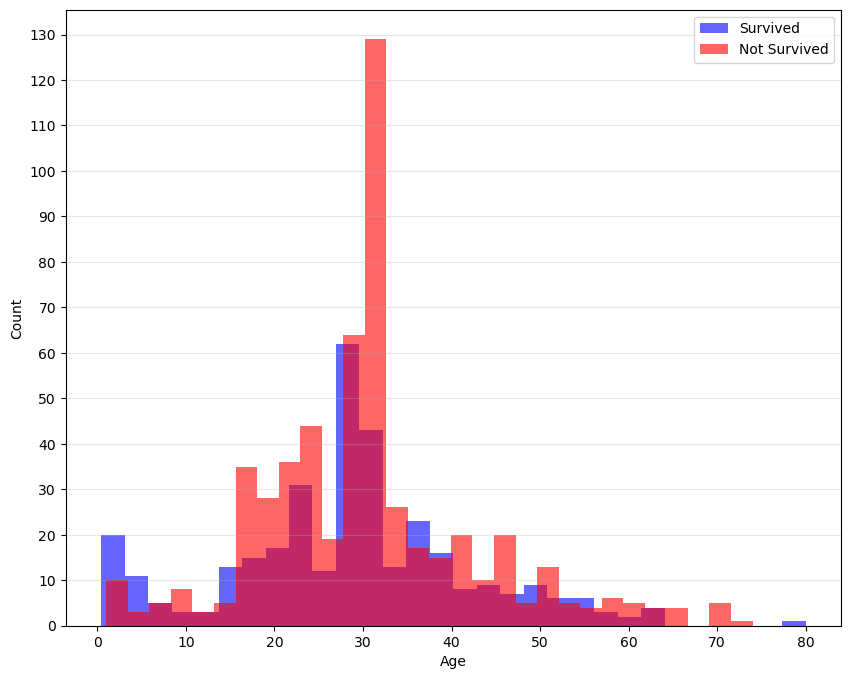

In [23]:
a = df[df["Survived"] == 1]["Age"].dropna()
b = df[df["Survived"] == 0]["Age"].dropna()

plt.figure(figsize=(10, 8))

plt.hist(a, bins=30, color='blue', alpha=.6, label='Survived')
plt.hist(b, bins=30, color='red', alpha=.6, label='Not Survived')


plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=.3, axis = 'y')
plt.yticks(range(0, 135, 10))
plt.show()

In [24]:
df[df["Survived"] == 0]["Age"].value_counts().head(1)

Age
30.726645    108
Name: count, dtype: int64

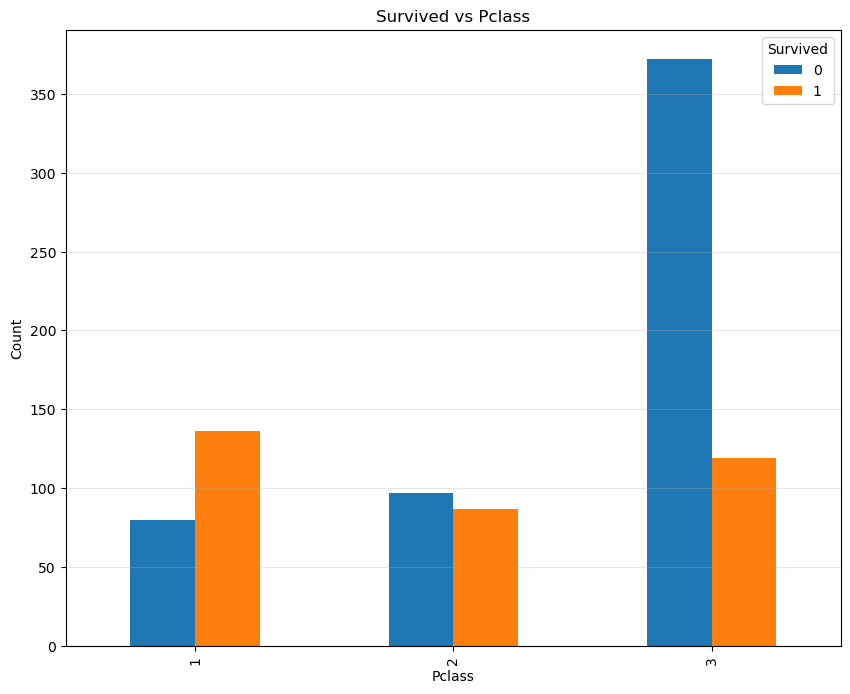

In [25]:
r = df.groupby("Pclass")["Survived"].value_counts().unstack()

r.plot(kind="bar", figsize=(10,8))
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Survived vs Pclass")
plt.grid(True, alpha=.3, axis='y')
plt.show()

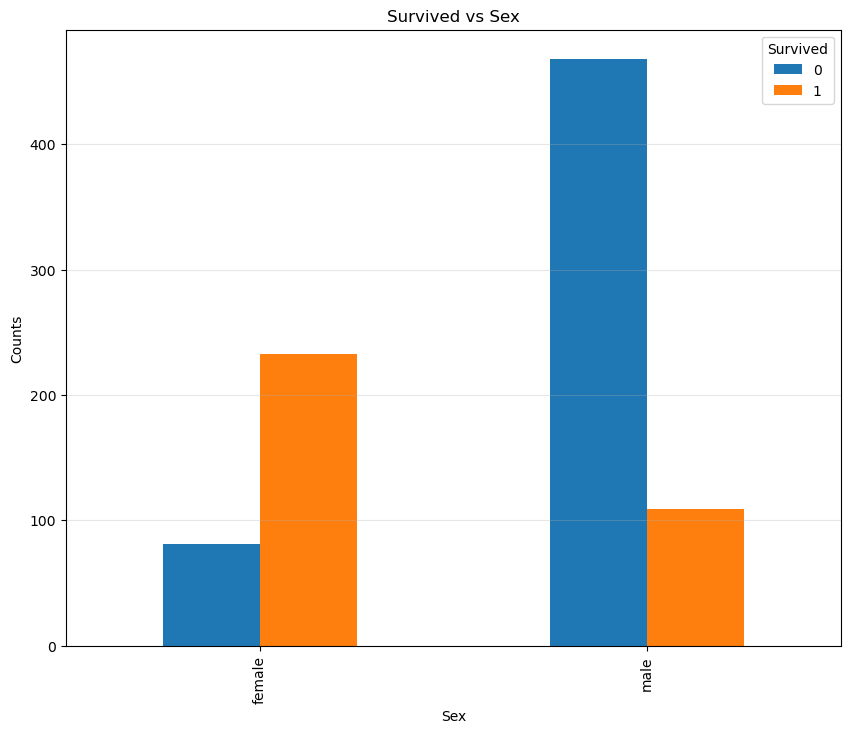

In [26]:
s = df.groupby("Sex")["Survived"].value_counts().unstack()
s.plot(kind = 'bar', figsize = (10, 8))

plt.xlabel("Sex")
plt.ylabel("Counts")
plt.title("Survived vs Sex")
plt.grid(True, alpha=.3, axis='y')
plt.show()

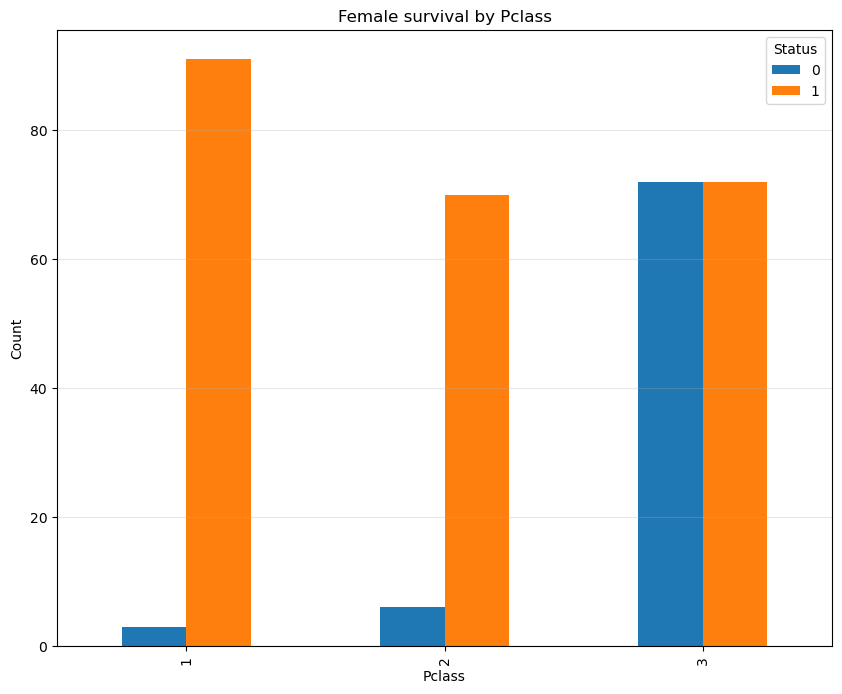

In [27]:
girls = df[df["Sex"] == "female"]

z = girls.groupby("Pclass")["Survived"].value_counts().unstack()

z.plot(kind="bar", figsize=(10, 8))

plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Female survival by Pclass")
plt.legend(title="Status")
plt.grid(True, alpha=.3, axis='y')
plt.show()

In [28]:
df.to_csv("titanic_training.csv", index = True)